In [61]:
import sys
sys.path.insert(0, '..')

In [62]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [63]:
objs = [
    "HD-139664",
    "HD109085",
    "GJ784-PSF",
    "PSF-5-K0",
    "GSC8056-0482",
    "GSC8491-1194",
    "GSC8894-0426",
    "HIP10679",
    "HIP107947",
    "HIP109901",
    "HIP112312A",
    "HIP112312B",
    "HIP114530",
    "HIP118008",
    "HIP12413",
    "HIP12545",
    "HIP12787B",
    "HIP17695",
    "HIP18859",
    "HIP19335",
    "HIP1993",
    "HIP21547",
    "HIP21632",
    "HIP23309",
    "HIP26990",
    "HIP2729",
    "HIP36627",
    "HIP37766",
    "HIP39896B",
    "HIP41889",
    "HIP50156",
    "HIP56445",
    "HIP6485",
    "HIP77199",
    "HIP9892",
    "HIP9902",
    "SSS1102-34",
    "TWA12",
    "TWA23",
    "TYC5672-0216",
    "G238-44",
]

In [64]:
objs[34]

'HIP9892'

In [65]:
len(objs)

41

In [66]:
wid = 80
oversample = 4

nwavels = 20
npoly=4

n_modes = 20
n_zernikes = 30

resolved_wid = 1

optics = NICMOSCoronagraph(512, wid, oversample, n_modes=n_modes, n_zernikes=n_zernikes)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'
# ddir = '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/repaired/'

flatdir = '../data/NICMOS-LAPL-DD2/LAPL_HOLEFLATS_DD2/'

vects = np.load("../data/iterative_spectrum_basis_F160W.npy")[:,:npoly]
assert vects.shape == (nwavels, npoly)
spectrum_basis = vects/np.sqrt(np.mean(vects**2, axis=0))

extra_bad = np.full((wid,wid), False).at[30:50, 30:50].set(True)#.at[:, 35:45].set(True)


exposures_single = [
    exposure_from_file(ddir + 'n8jv53y9q_o_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid, extra_bad=None, flatcorr=flatdir),
    # exposure_from_file(ddir + 'n8zu85ndq_m_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid),
]


31.95922 5.4
Version 4.1.1
-70.5301


ADCZERO                    0.0 / analog-digital conversion zero level (DN)       [astropy.io.fits.card]


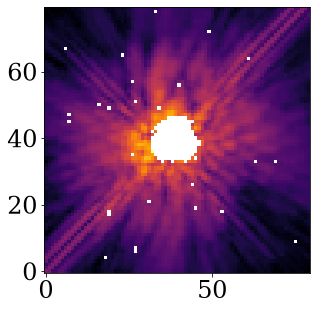

In [67]:
plt.imshow(exposures_single[0].data**0.125)

In [68]:
256-181,256-44

(75, 212)

In [69]:
exposures_single[0].hdr["TARSIAFY"]

211.898

In [70]:
# np.array([
#         256-181 - np.array(exp.hdr["TARSIAFX"],dtype=float), 
#         256-44 - np.array(exp.hdr["TARSIAFY"],dtype=float)
#     ])*0.075

In [71]:
exposures_single[0].target

'BD+032954'

In [72]:
(np.nansum(exposures_single[0].data)/nwavels)*4

Array(69992.10966914, dtype=float64)

In [73]:
params = {
    "spectrum": {},
    "primary_opd": {},
    "primary_low": {},
    "primary_tilt": {},
    "cold_mask_opd": {},
    "cold_mask_tilt": {},
    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_shear": {},
    "cold_mask_scale": {},
    "primary_rot": {},
    "primary_shear": {},

    "bias": {},
    "occulter_radius": 0.7,
    "occulter_coeffs": np.zeros(2)+1,
    "fnumber": 45.7,
}


for idx, exp in enumerate(exposures_single):
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels)*4)

    params["primary_tilt"][exp.fit.get_key(exp, "primary_tilt")] = np.array([-0.05, -0.75])*0.075
    # params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([-0.2167105 , -0.17420508])#*0.
    params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([
        np.array(exp.hdr["TARSIAFX"],dtype=float) - (256-181), 
        np.array(exp.hdr["TARSIAFY"],dtype=float) - (256-44)
    ])*0.075


    params["primary_opd"][exp.fit.get_key(exp, "primary_opd")] = np.zeros((n_modes, n_modes))
    params["primary_low"][exp.fit.get_key(exp, "primary_low")] = np.zeros((n_zernikes))
    params["cold_mask_opd"][exp.fit.get_key(exp, "cold_mask_opd")] = np.array([120.])

    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.array([13.,10.]) #np.asarray([-13.,-7.])#
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = 0.25#-90.
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -0.6##-90.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    

model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))

params = ModelParams(params)

51.203288297954316


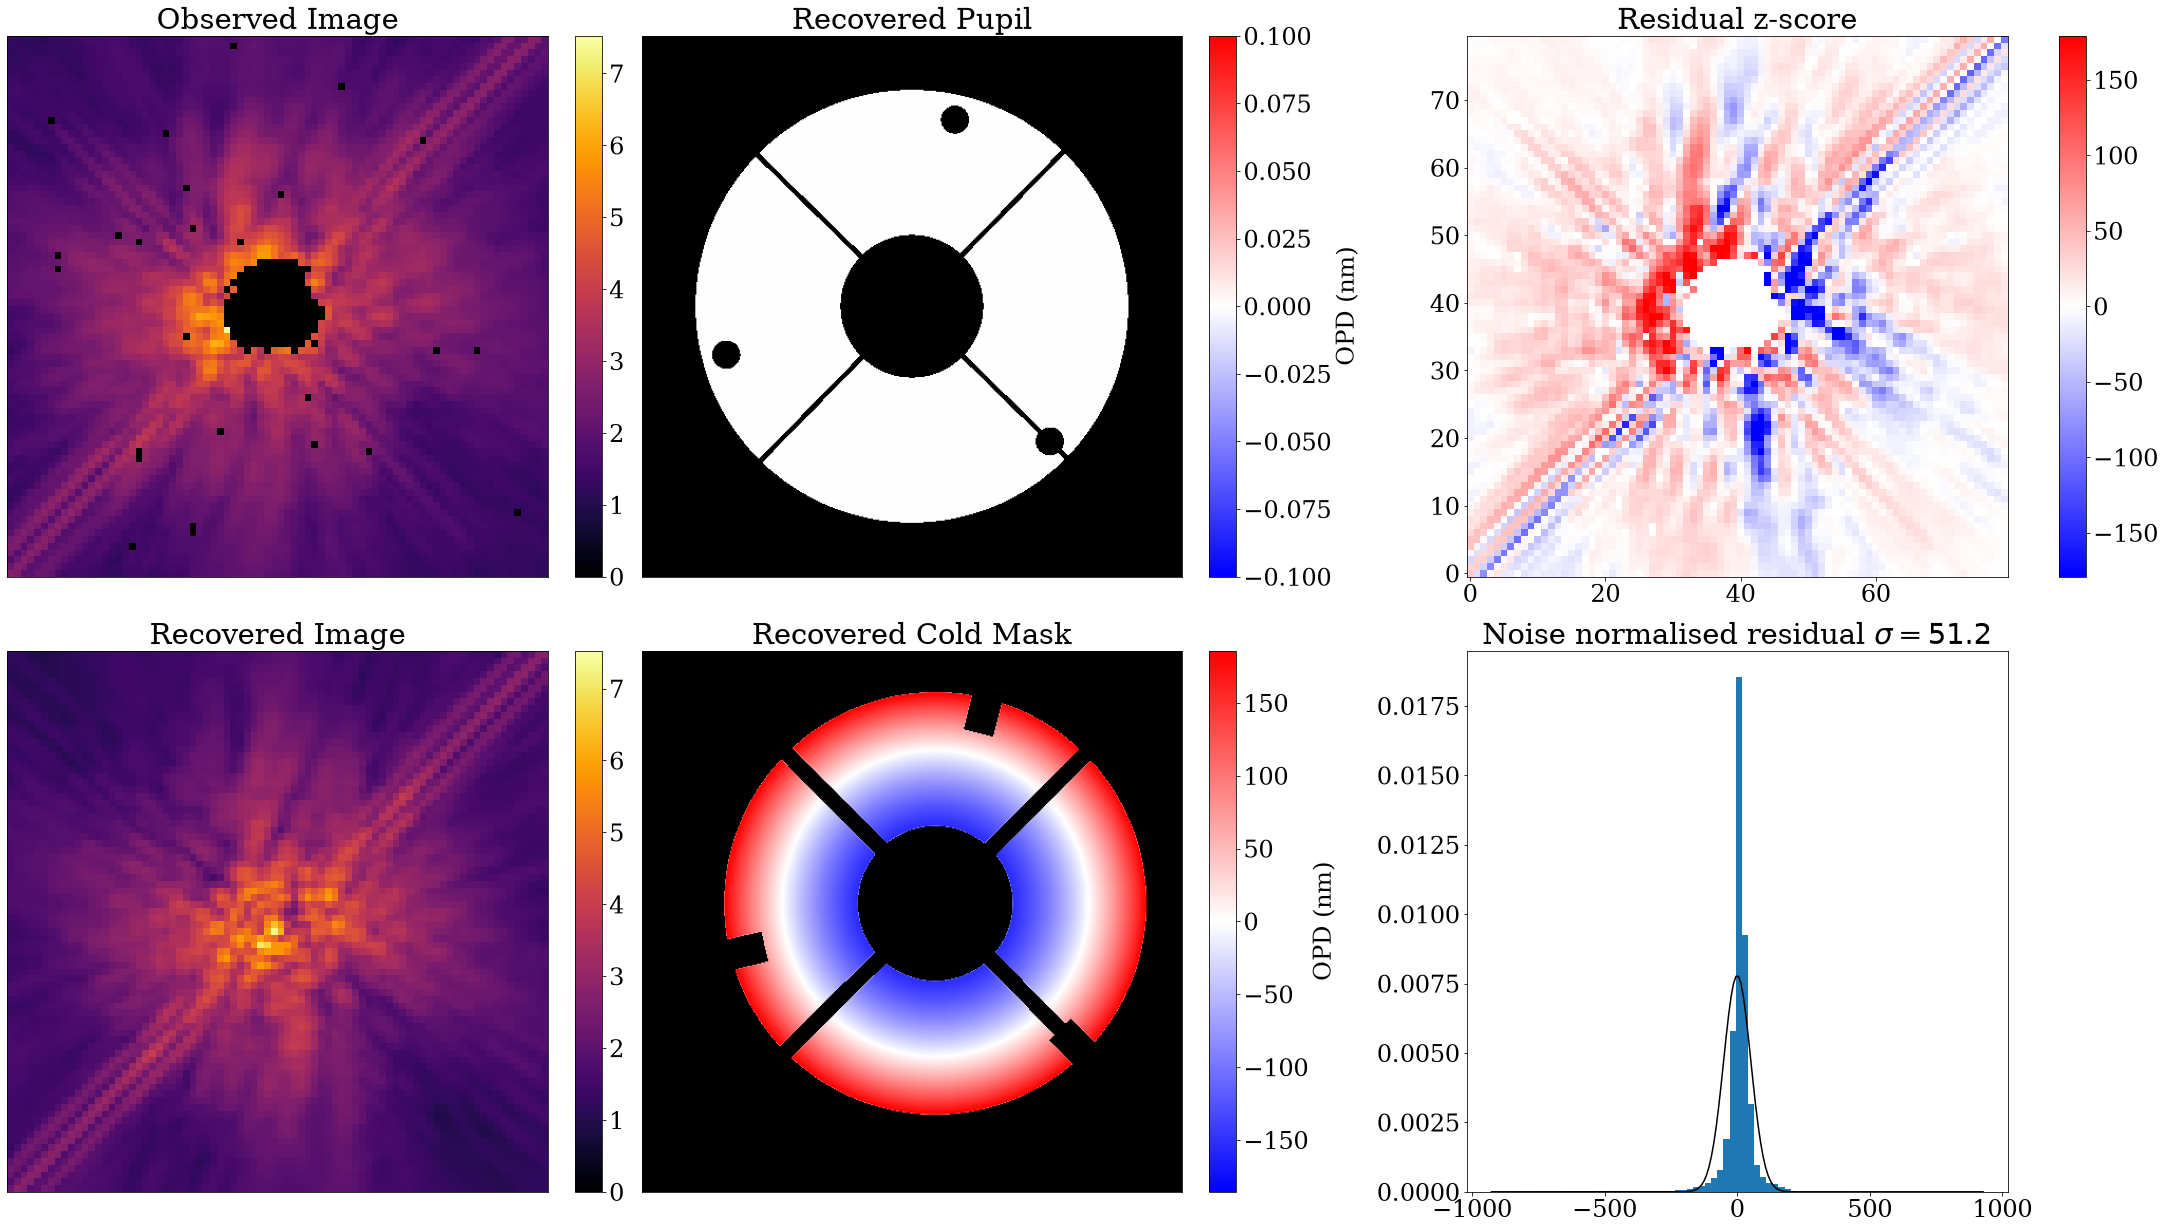

In [74]:
plot_comparison(model_single, params, exposures_single, percentile=99, wf_size=512)

In [75]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)

def adam(lr, delay):
    return optax.adam(zdx.optimisation.delay(lr, delay))


g = 5e-2

"""
    "spectrum": sgd(g*3, 0),
    "cold_mask_shift": sgd(g*20, 40),
    
    "bias": sgd(g*3, 20),
    "primary_opd": sgd(g*0.1, 10),
    # "primary_opd": adam(0.1, 10),

    "cold_mask_opd": sgd(g*3, 10),

    "primary_tilt": sgd(g*1, 10),
    "cold_mask_tilt": sgd(g*1, 10),
    #"jitter": opt(g*1, 120),


    "cold_mask_shear": sgd(g*2, 200),
    "cold_mask_rot": sgd(g*3, 200),
    "cold_mask_scale": sgd(g*15, 200),

    # "quadrature": sgd(g*20, 400)

    "occulter_radius": sgd(g*10, 200),
    "fnumber": sgd(g*0.05, 220),

    "occulter_coeffs": sgd(g*20, 300),
"""

things = {
    "primary_opd": sgd(g*0.5, 0),

    "spectrum": sgd(g*3, 0),
    "primary_tilt": sgd(g*3, 0),
    "cold_mask_tilt": sgd(g*3, 0),
    "cold_mask_opd": sgd(g*1, 0),

    "bias": sgd(g*3, 0),
    "cold_mask_shift": sgd(g*3, 0),
    "cold_mask_rot": sgd(g*0.2, 0),
    "primary_rot": sgd(g*1, 0),

    "primary_low": sgd(g*1, 0),

    "cold_mask_scale": sgd(g*1, 0),
    "cold_mask_shear": sgd(g*1, 0),

    "occulter_radius": sgd(g*1., 0),
    # "occulter_coeffs": sgd(g*1, 0),


}

things_start = {
    "spectrum": sgd(g*3, 30.),
    "primary_tilt": sgd(g*10, 15.),
    "cold_mask_tilt": sgd(g*1, 0),
    "cold_mask_opd": sgd(g*3, 40),

    "bias": sgd(g*3, 50),
    "cold_mask_shift": sgd(g*3, 70),
    "cold_mask_rot": sgd(g*0.2, 85),
    "primary_rot": sgd(g*1, 85),

    "primary_low": sgd(g*0.5, 150),

    "cold_mask_scale": sgd(g*5, 100),
    "cold_mask_shear": sgd(g*10, 100),

    "primary_shear": sgd(g*5, 100),

    "occulter_radius": sgd(g*1., 120),
    "occulter_coeffs": sgd(g*5, 120),
    "fnumber": sgd(g*2., 200),
}

groups = list(things.keys())

In [76]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [77]:
losses, params_history = optimise_new(
    opt_params, model_single, exposures_single, things_start, 300,
    precond_method="gn_exact", precond_kwargs=dict(chunk=16))

  0%|          | 0/300 [00:00<?, ?it/s]

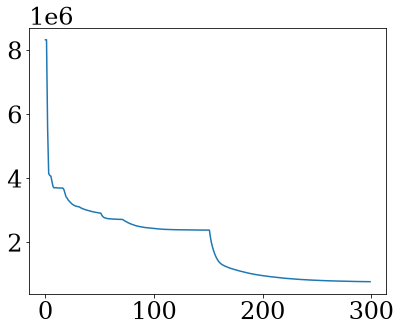

In [78]:
plt.plot(losses[:])

15
15.693459510853858


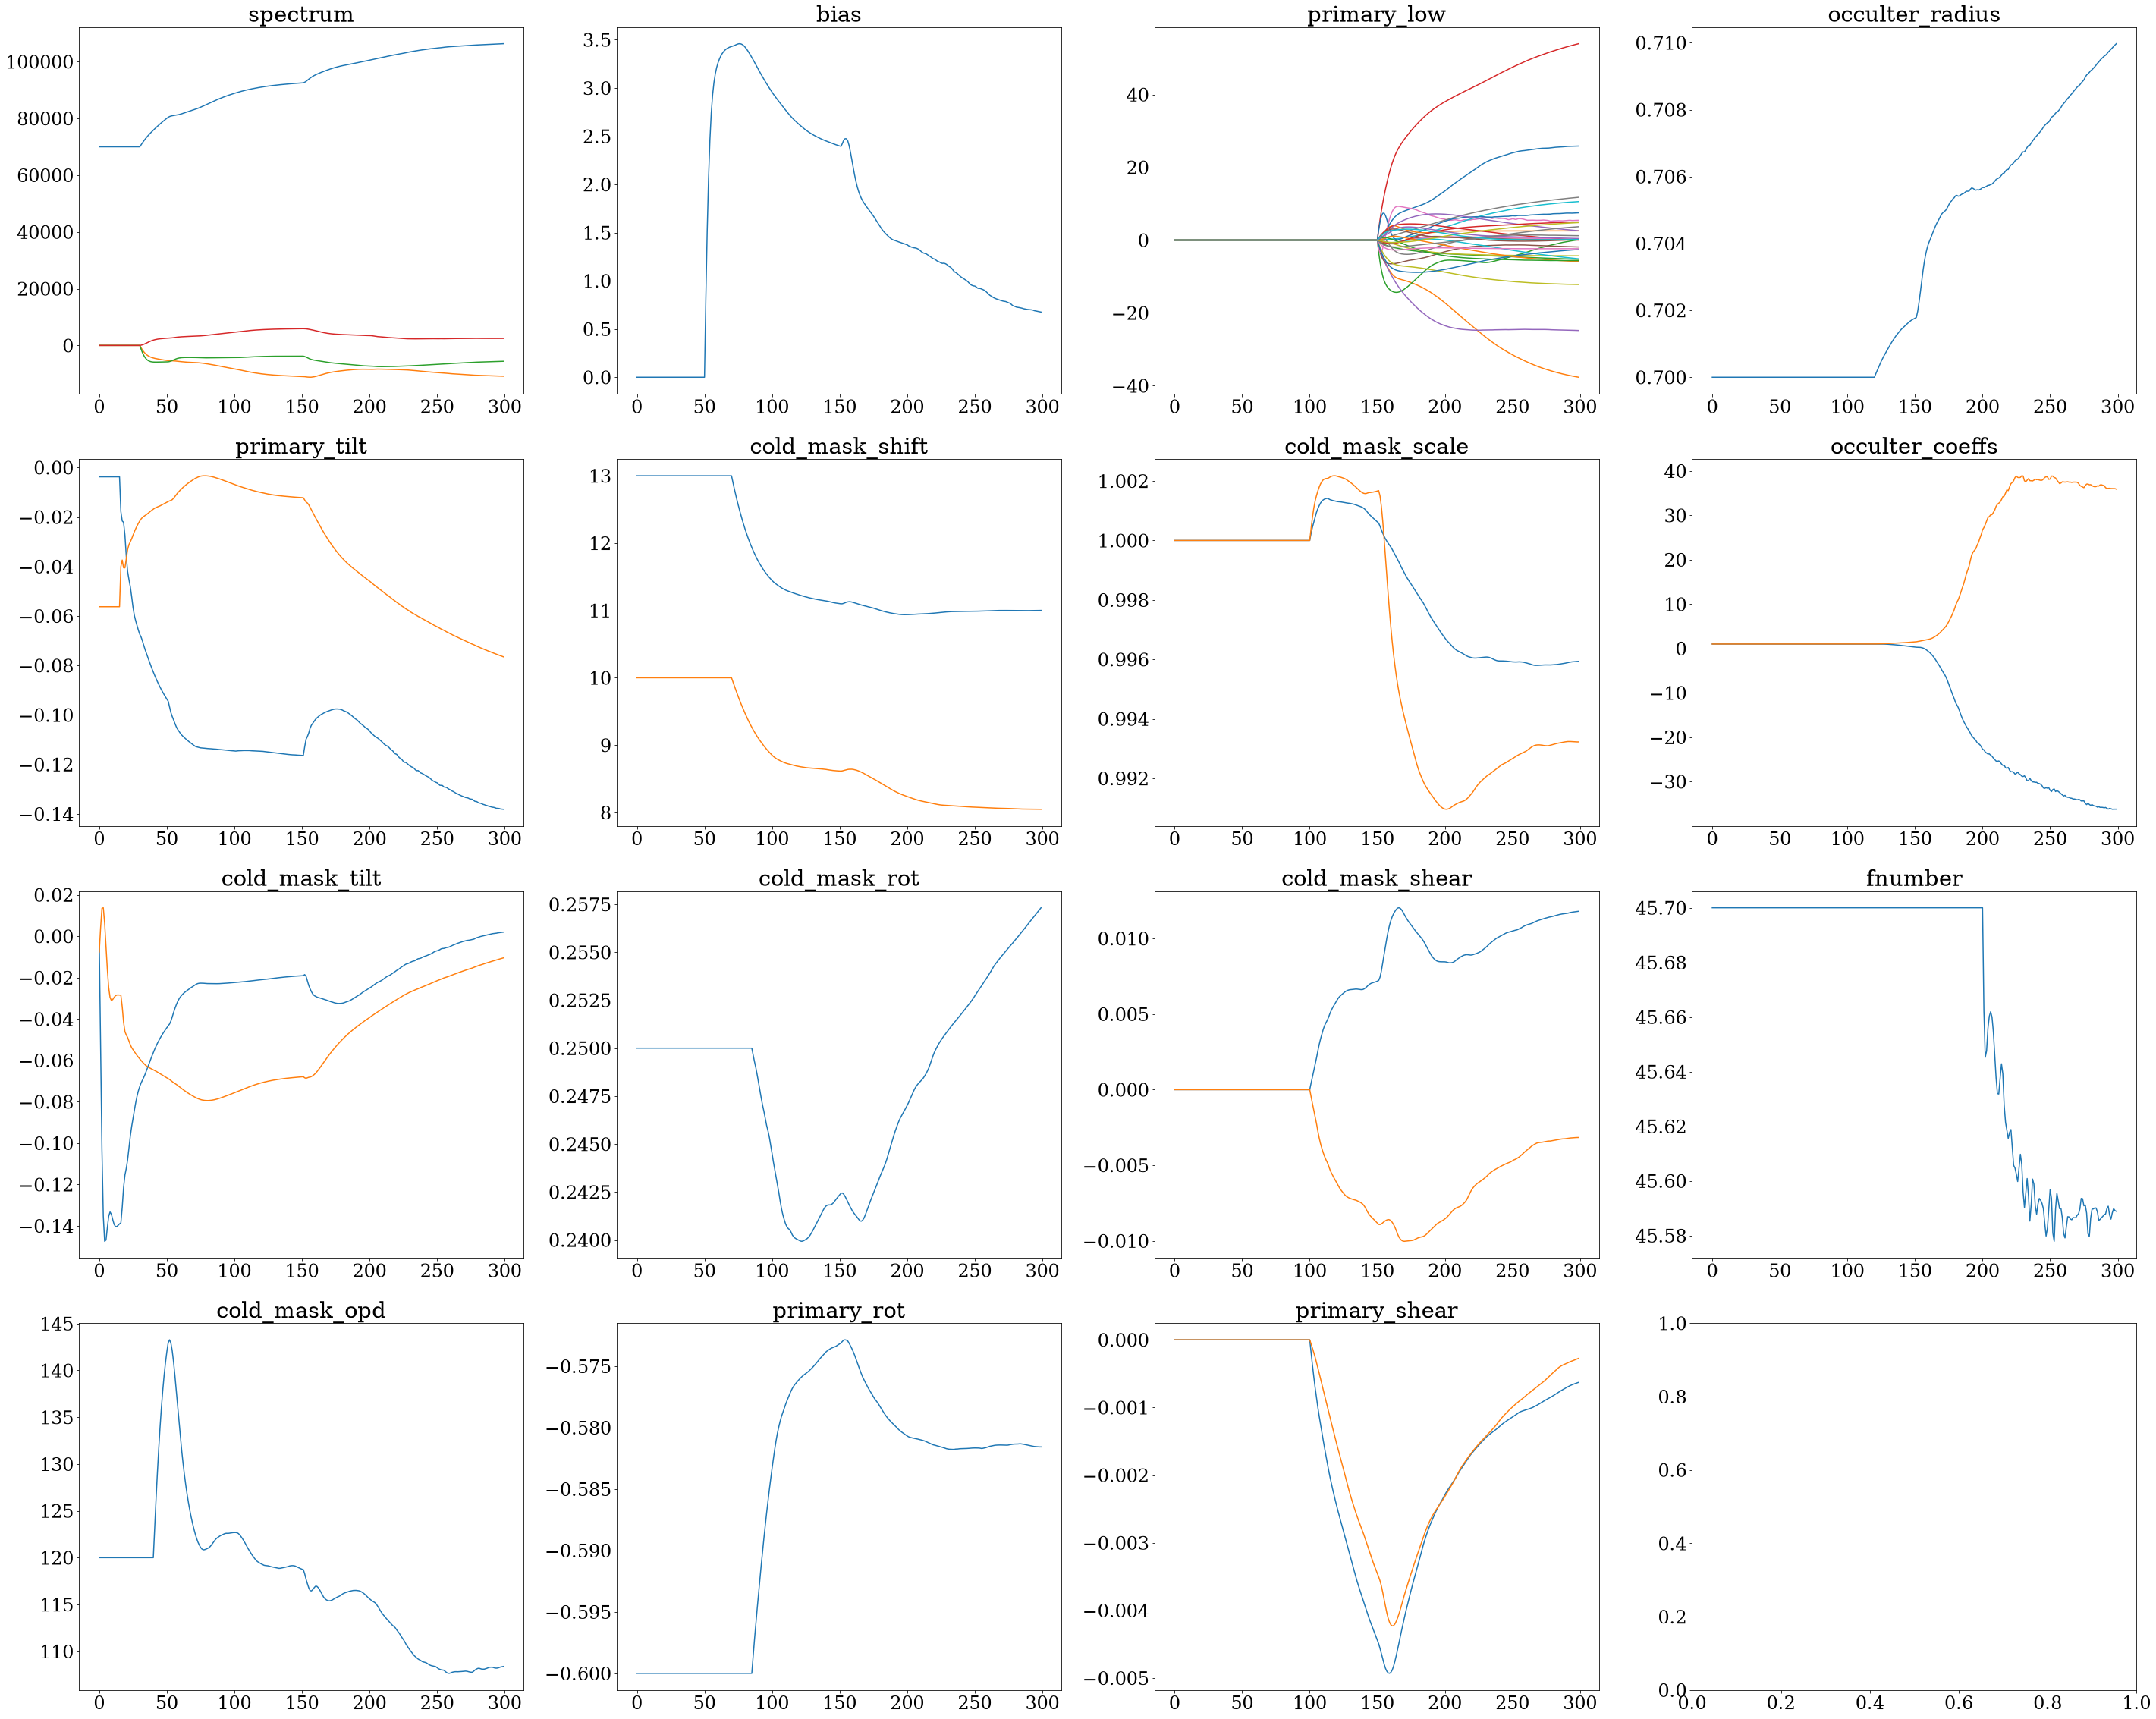

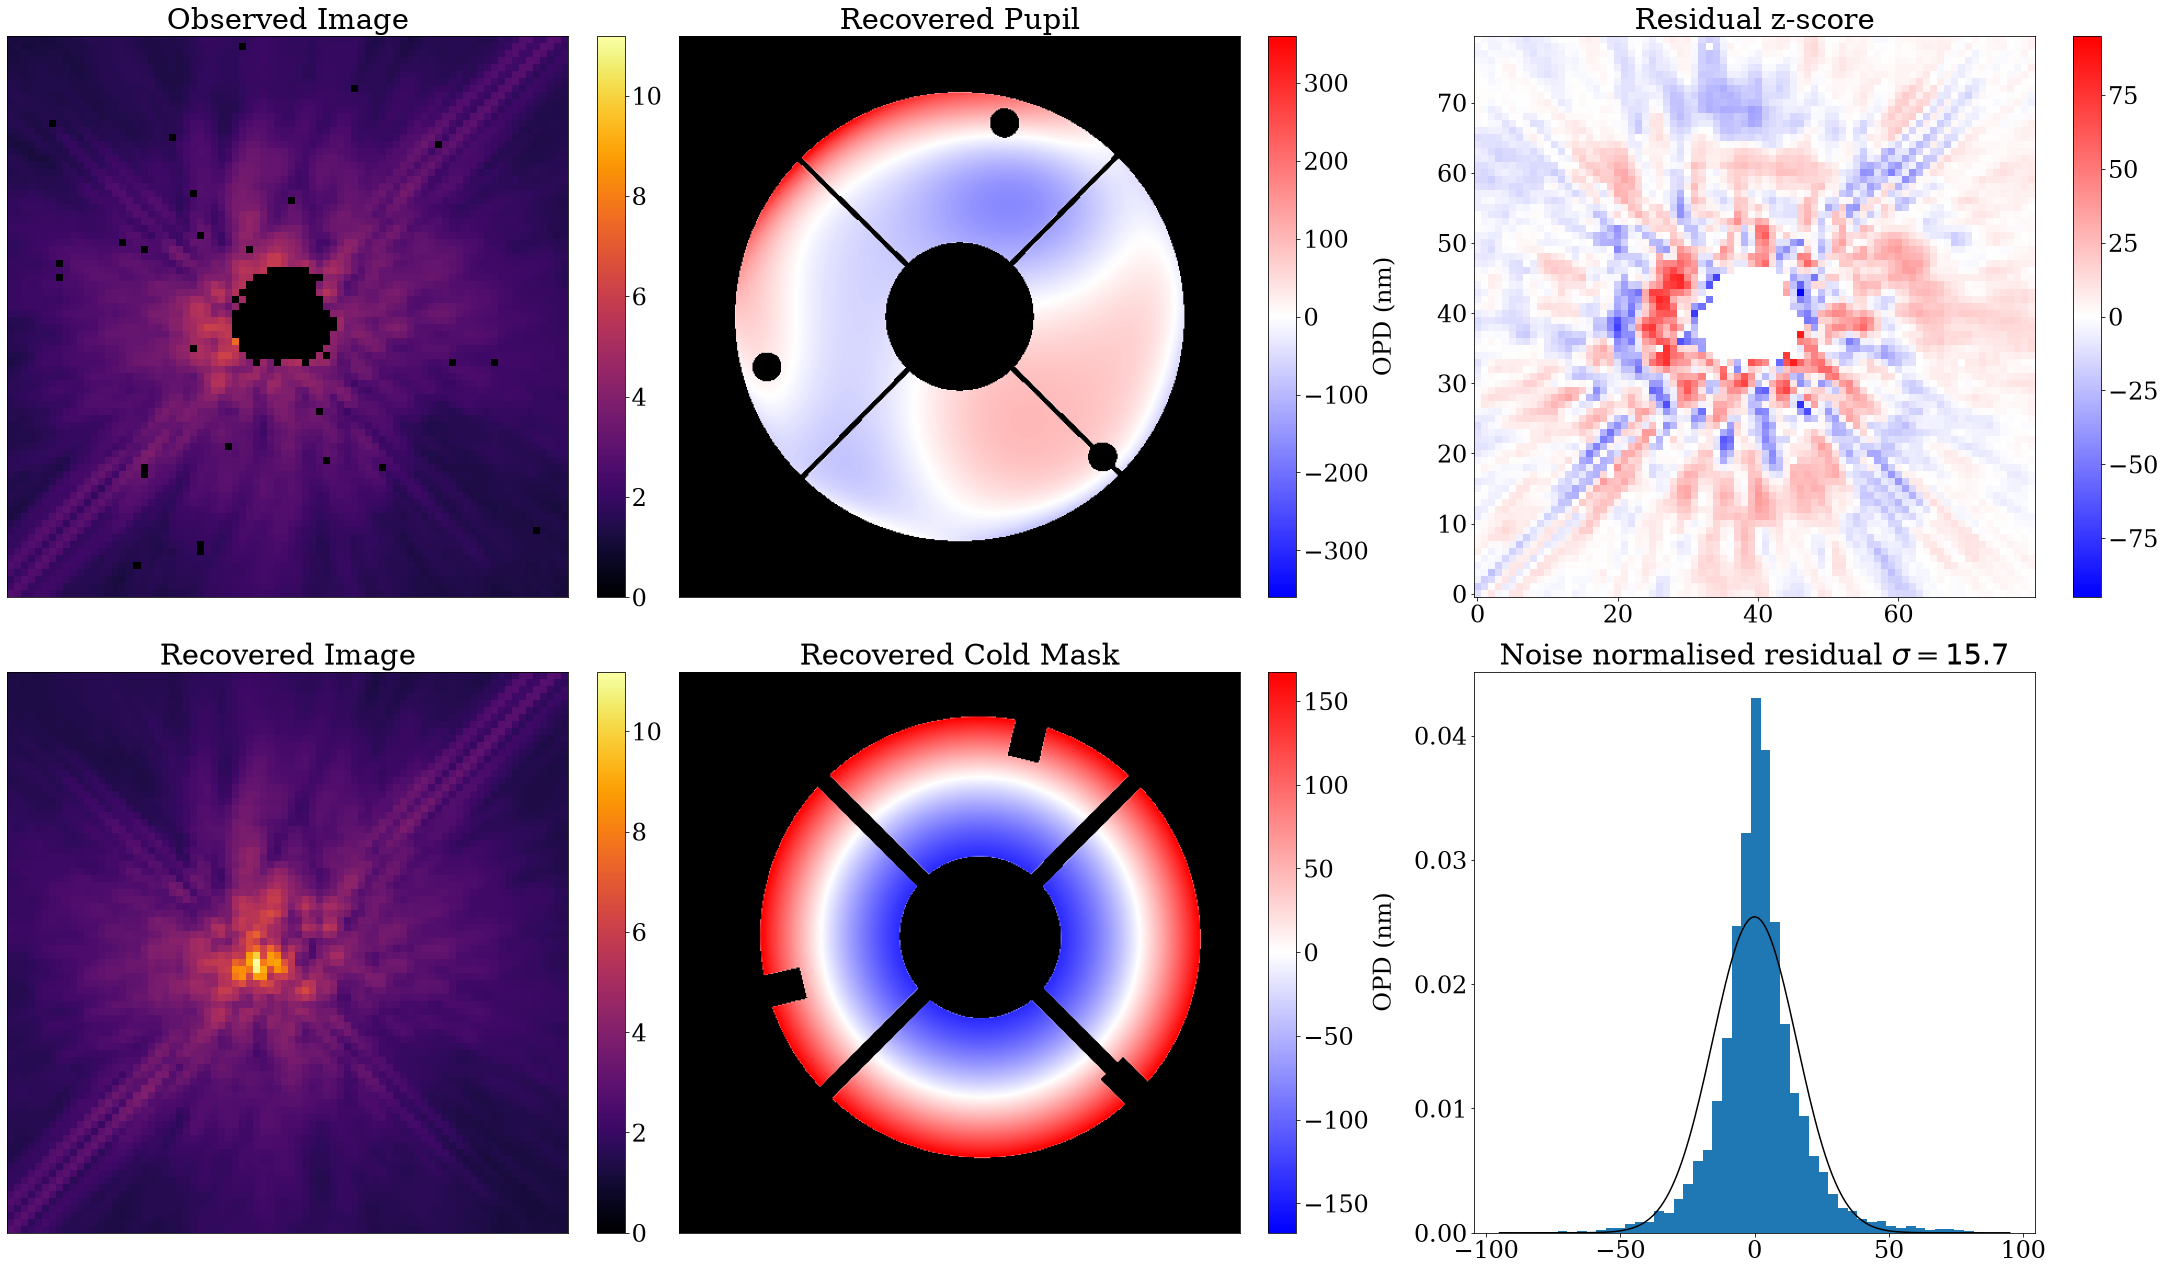

In [79]:
plot_params(params_history, list(things_start.keys()), xw = 4)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, percentile=100, quadrature=False, wf_size=512)

In [80]:
# stop

In [81]:
final_model = ModelParams(params_history[-1]).inject(model_single)
final_optics = exposures_single[0].fit.update_optics(final_model, exposures_single[0])

In [82]:
dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)

Wavefront(
  phasor=c128[128,128], wavelength=f64[], pixel_scale=f64[], center=f64[1]
)

In [83]:
dlu.arcsec2rad(0.3)*24*2.4

8.37758040957278e-05

In [84]:
testocculter = dl.CircularAperture(dlu.arcsec2rad(0.3)*24*2.4)

In [85]:
# testocculter = CLIMBOcculter(dlu.arcsec2rad(0.3)*24*2.4, np.zeros(1)+3e-3, np.zeros(1))
final_optics.occulter.layers["occulter"]

CLIMBOcculter(r=f64[], cc=f64[1], ss=f64[1], normalise=False)

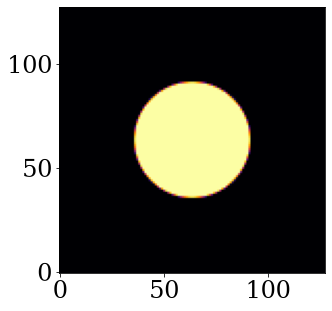

In [86]:
plt.imshow(np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

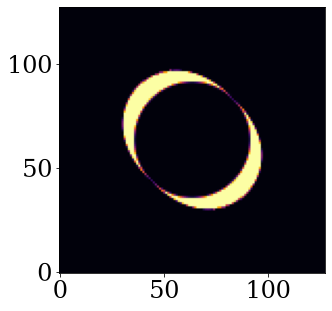

In [87]:
plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor)- np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

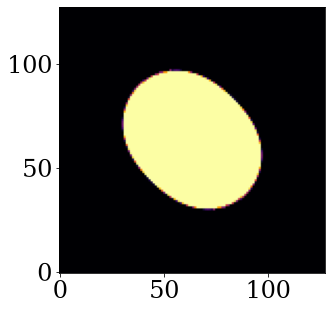

In [88]:
plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

In [89]:
params_history[-1]

{'bias': {'n8jv53y9q': Array(0.6760236, dtype=float64)},
 'cold_mask_opd': {'global': Array([108.38267637], dtype=float64)},
 'cold_mask_rot': {'global': Array(0.25732062, dtype=float64)},
 'cold_mask_scale': {'global': Array([0.99593601, 0.99322596], dtype=float64)},
 'cold_mask_shear': {'global': Array([ 0.01179725, -0.00316231], dtype=float64)},
 'cold_mask_shift': {'global': Array([11.00079238,  8.04731816], dtype=float64)},
 'cold_mask_tilt': {'global': Array([ 0.00199389, -0.01047572], dtype=float64)},
 'fnumber': Array(45.58889075, dtype=float64),
 'occulter_coeffs': Array([-36.21523939,  35.88857768], dtype=float64),
 'occulter_radius': Array(0.70997084, dtype=float64),
 'primary_low': {'n8jv53y9q': Array([ 2.58492731e+01, -3.76806999e+01,  9.96928764e-02,  5.39613622e+01,
         -2.48408255e+01, -1.89141935e+00,  5.44081382e+00,  1.17590124e+01,
         -1.22019753e+01,  1.05816118e+01,  7.49862942e+00,  2.53882008e+00,
         -5.28730223e+00, -1.65379545e-02,  2.56329162

In [90]:
stop

NameError: name 'stop' is not defined

In [ ]:
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [ ]:
losses, params_history = optimise_new(
    opt_params, model_single, exposures_single, things, 400,
    precond_method="gn_probe", precond_kwargs=dict(n_probes=32))

  0%|          | 0/400 [00:00<?, ?it/s]

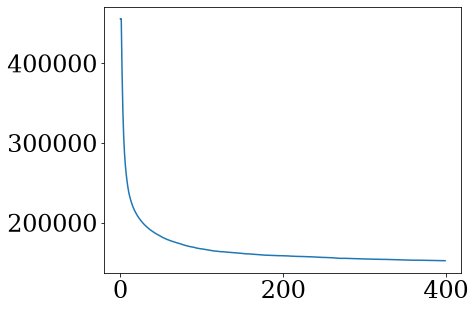

In [ ]:
plt.plot(losses[:])

In [ ]:
losses[-1]

Array(152295.38103951, dtype=float64)

13
6.987301153224592


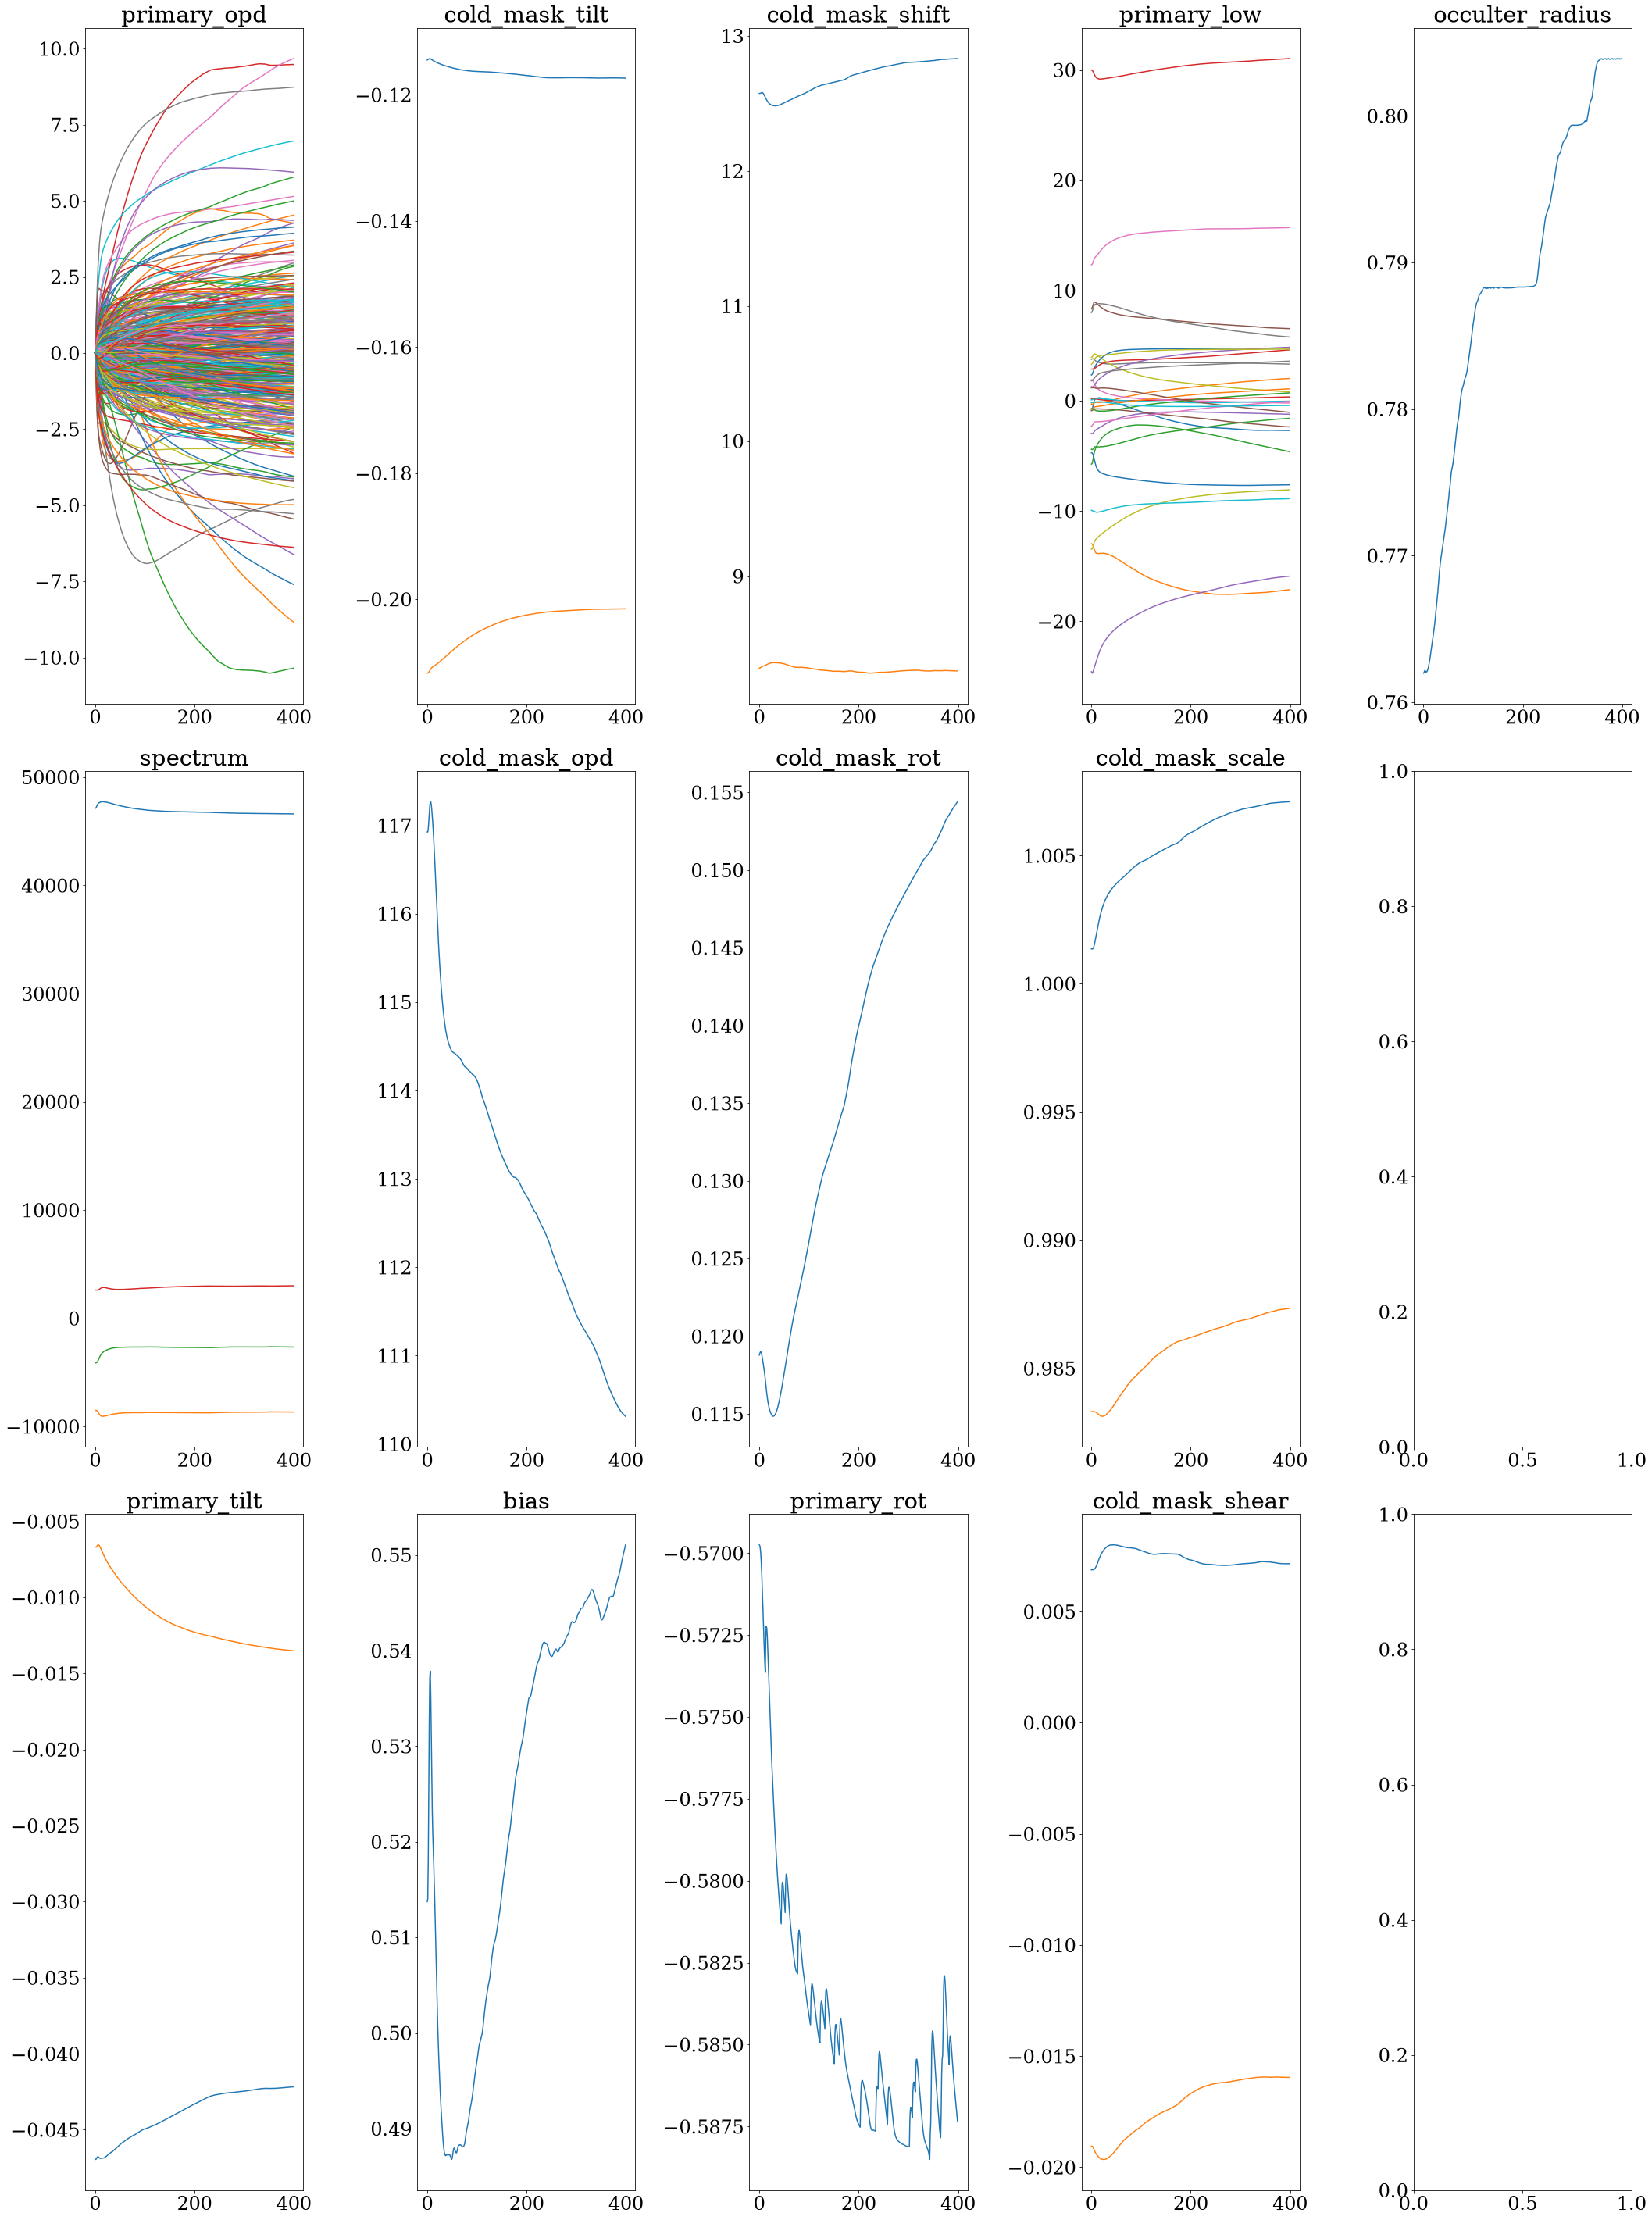

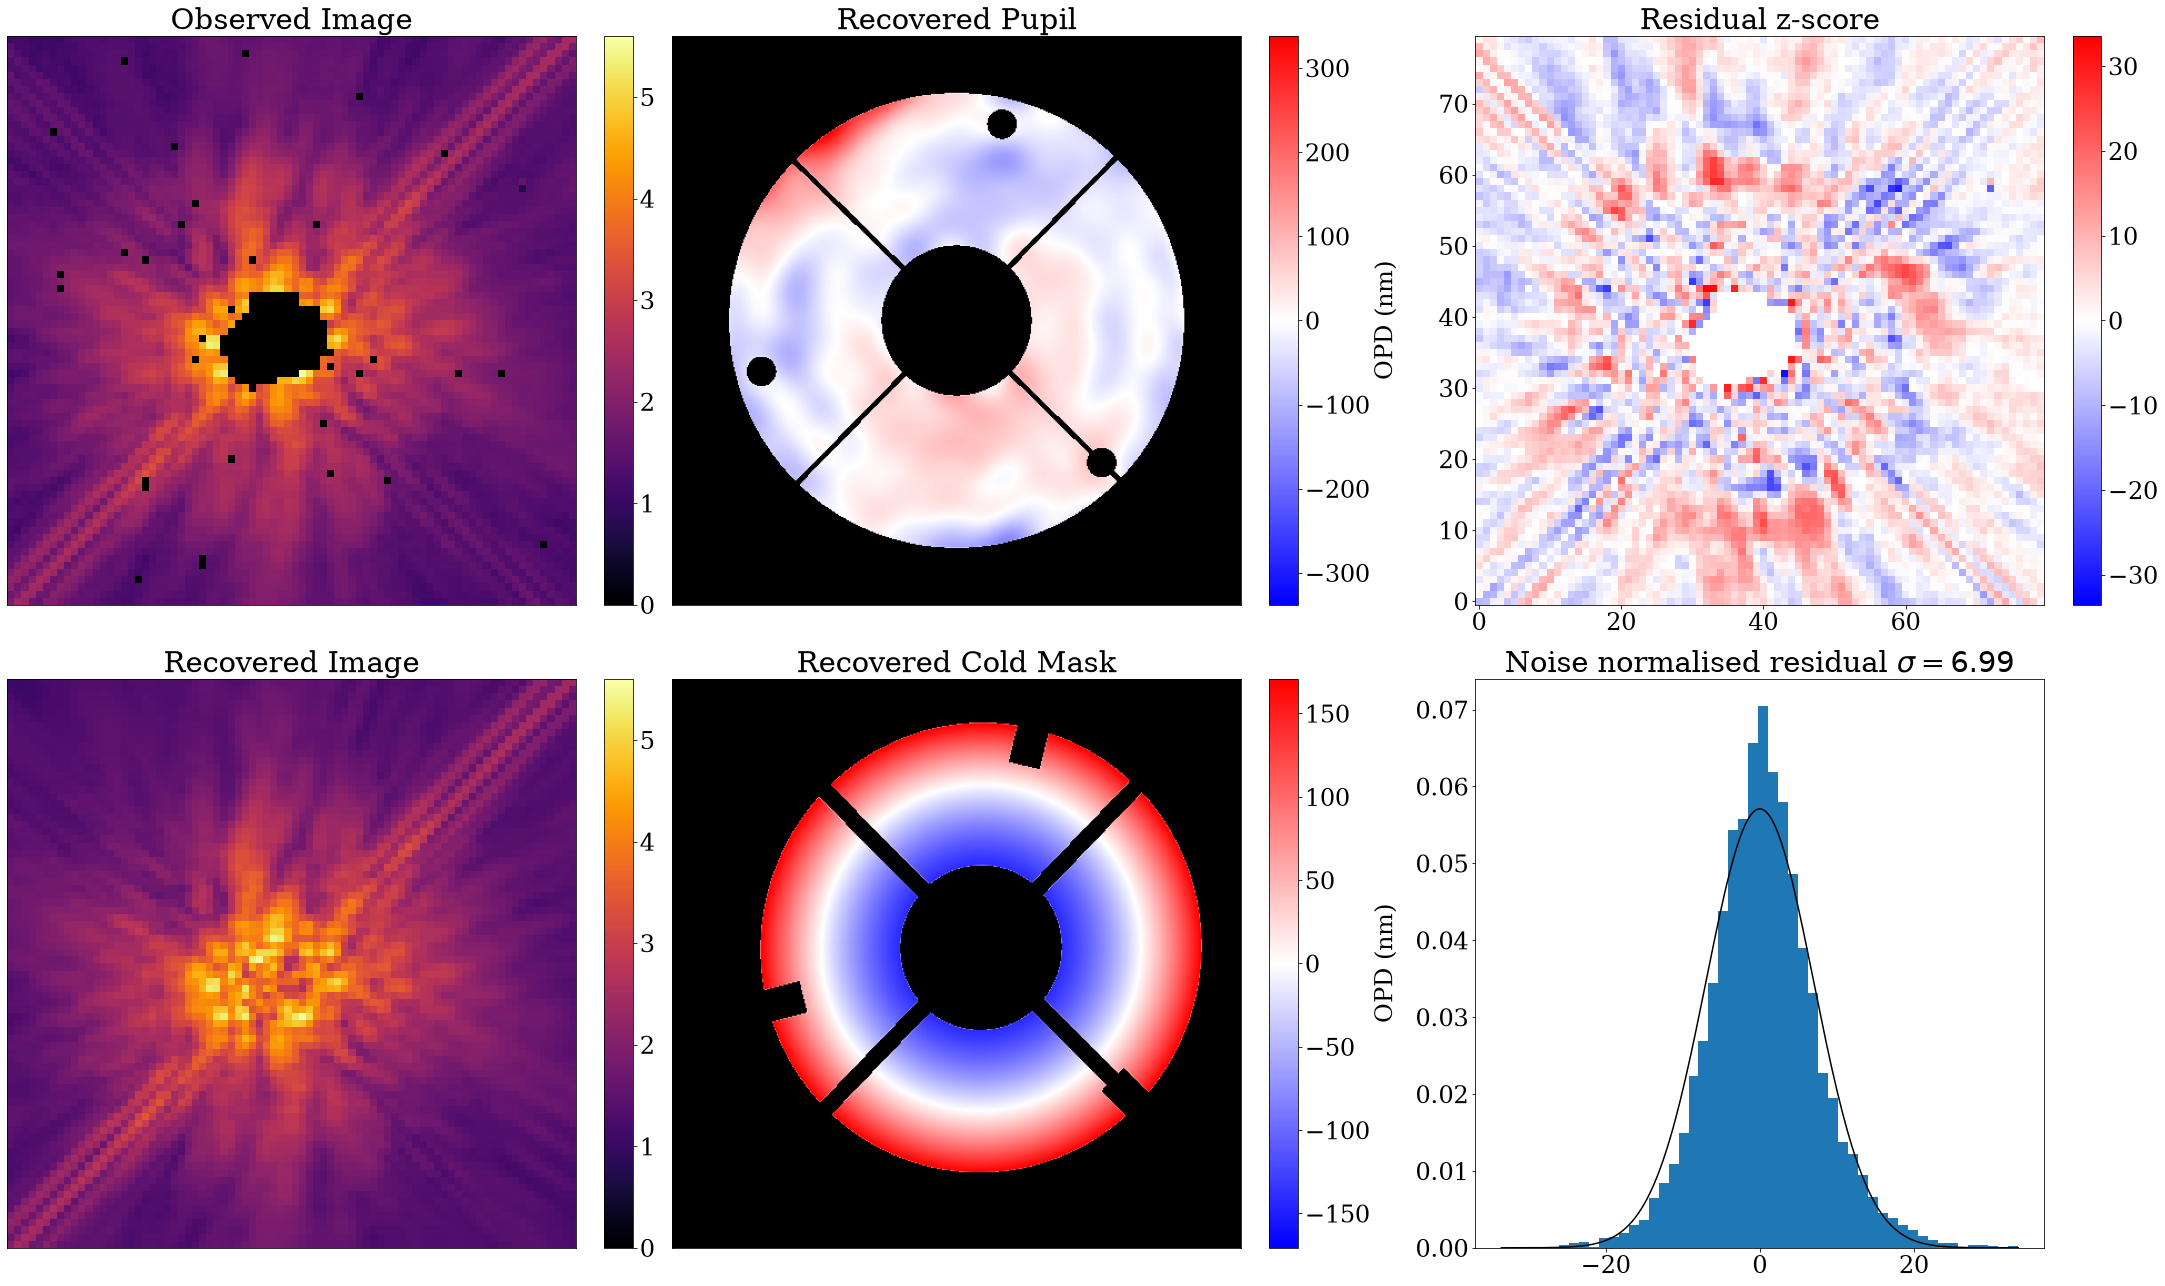

In [ ]:
plot_params(params_history, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=False)

In [ ]:
params_history[-1]

{'bias': {'n8zu85ncq': Array(0.55106135, dtype=float64)},
 'cold_mask_opd': {'global': Array([110.31263234], dtype=float64)},
 'cold_mask_rot': {'global': Array(0.15440119, dtype=float64)},
 'cold_mask_scale': {'global': Array([1.0071049 , 0.98734039], dtype=float64)},
 'cold_mask_shear': {'global': Array([ 0.00715539, -0.01595675], dtype=float64)},
 'cold_mask_shift': {'global': Array([12.83168715,  8.29810288], dtype=float64)},
 'cold_mask_tilt': {'global': Array([-0.11734838, -0.20151841], dtype=float64)},
 'occulter_radius': Array(0.80388954, dtype=float64),
 'primary_low': {'n8zu85ncq': Array([ -2.69471972, -17.13407731,  -4.62222183,  31.03068787,
         -15.90778501,   6.54119513,  15.70128809,   5.77860058,
          -8.08033465,  -8.88405716,  -7.62643572,   2.020786  ,
          -1.59139229,   0.34884407,  -1.22766949,  -2.37575222,
          -0.21099774,   3.32330361,   0.7990813 ,  -0.03449056,
           4.76586969,   1.08200247,   0.71411444,   4.61740116,
           4.

In [ ]:
np.save("params.npy", params_history[-1])

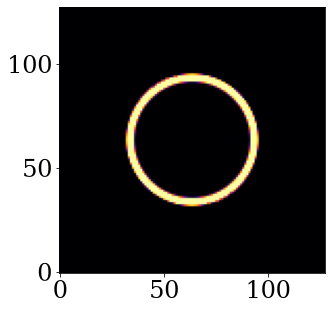

In [ ]:
final_model = ModelParams(params_history[-1]).inject(model_single)
final_optics = exposures_single[0].fit.update_optics(final_model, exposures_single[0])
testocculter = dl.CircularAperture(dlu.arcsec2rad(0.3)*24*2.4)

plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor)- np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))